/tmp/ipykernel_64243/1597498801.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


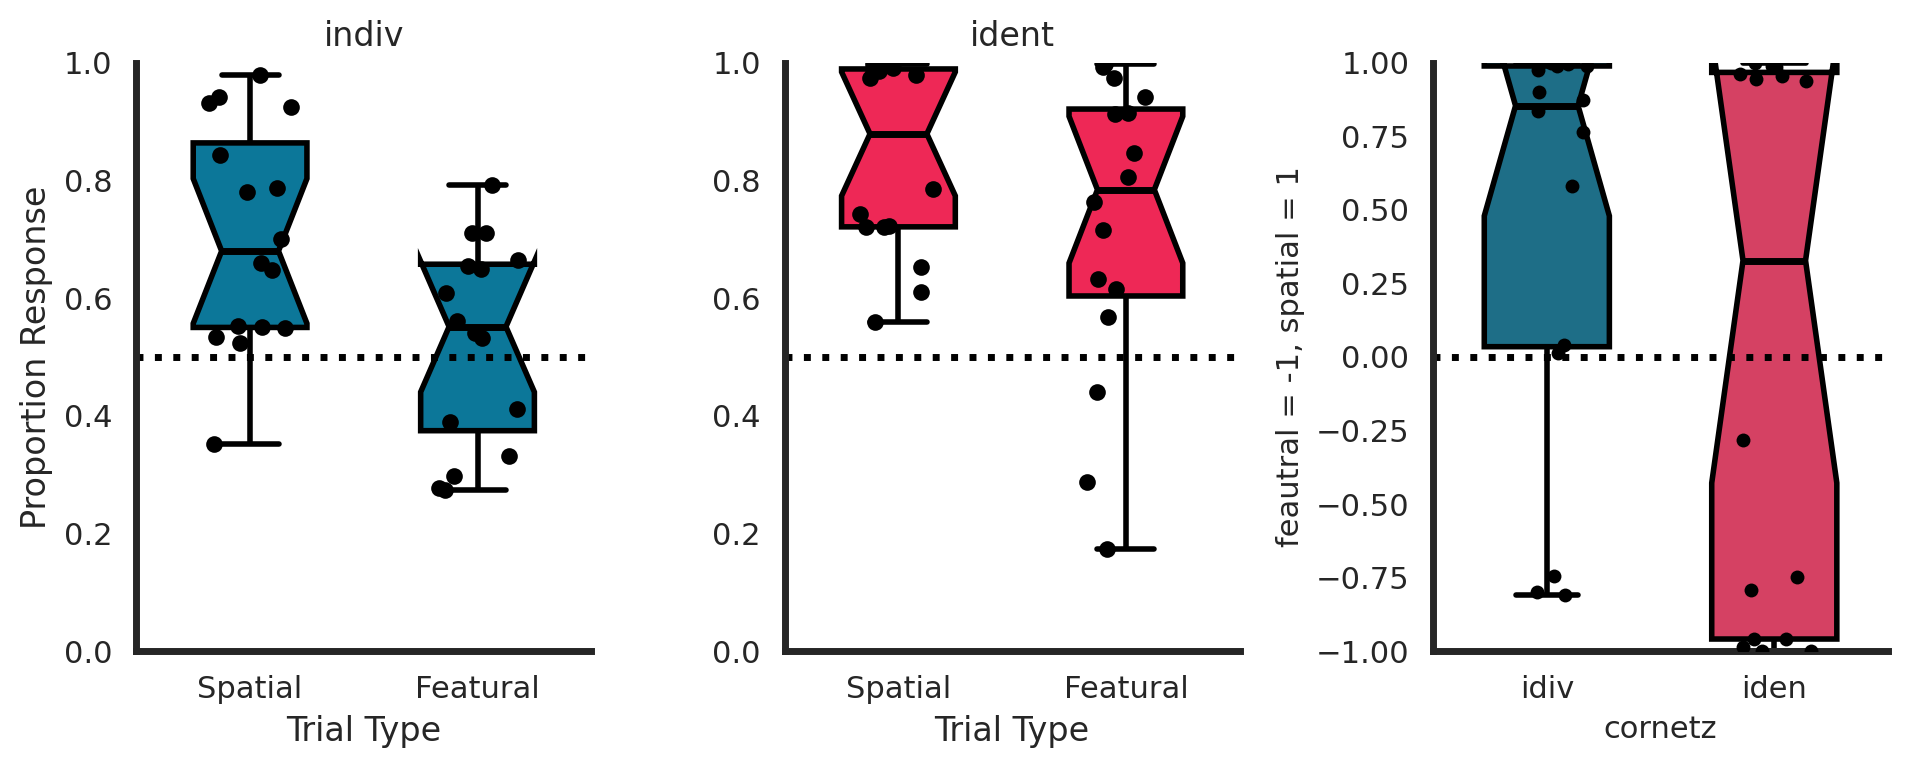

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# EDIT THESE PATHS
# -----------------------
CSV1 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation/results/geogaze_model_predictions_individuation_pred_avg_ratio.csv"
CSV2 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/identification/results/geogaze_model_predictions_identification_pred_avg_ratio.csv"

# -----------------------
# Preprocess A: Spatial vs Featural (mean_ratio per model×condition)
# -----------------------
def load_and_preprocess(csv_path: str) -> pd.DataFrame:
    """
    Reads a CSV with columns: model, condition (spatial/featural/...), ratio
    Keeps only spatial + featural rows, then averages ratio within each model×condition.
    Returns a df with columns: model, condition (Spatial/Featural), mean_ratio
    """
    df = pd.read_csv(csv_path)

    df["condition"] = df["condition"].astype(str).str.strip().str.lower()
    df = df[df["condition"].isin(["spatial", "featural"])].copy()

    df["ratio"] = pd.to_numeric(df["ratio"], errors="coerce")
    df = df.dropna(subset=["ratio"])

    df_avg = (
        df.groupby(["model", "condition"], as_index=False)["ratio"]
          .mean()
          .rename(columns={"ratio": "mean_ratio"})
    )

    df_avg["condition"] = df_avg["condition"].map({"spatial": "Spatial", "featural": "Featural"})
    return df_avg

# -----------------------
# Preprocess B: Conflict -> signed weighting (one dot per model)
# -----------------------
def load_conflict_weighting(csv_path: str, dataset_label: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    df["condition"] = df["condition"].astype(str).str.strip().str.lower()
    df["ratio"] = pd.to_numeric(df["ratio"], errors="coerce")
    df = df.dropna(subset=["ratio"])

    # keep ONLY conflict rows
    df_conf = df[df["condition"].eq("conflict")].copy()

    # average conflict ratio per model (one dot per model)
    conf_avg = (
        df_conf.groupby("model", as_index=False)["ratio"]
               .mean()
               .rename(columns={"ratio": "conflict_ratio"})
    )

    # Convert to signed weighting where + = spatial, - = featural
    # given: conflict_ratio > 0.5 = featural, < 0.5 = spatial
    conf_avg["weighting"] = (0.5 - conf_avg["conflict_ratio"]) * 2

    conf_avg["dataset"] = dataset_label
    return conf_avg

# -----------------------
# Load all data (from the SAME CSVs)
# -----------------------
df1_avg  = load_and_preprocess(CSV1)                 # indiv: Spatial/Featural
df2_avg  = load_and_preprocess(CSV2)                 # ident: Spatial/Featural
df1_conf = load_conflict_weighting(CSV1, "idiv")     # conflict weighting
df2_conf = load_conflict_weighting(CSV2, "iden")     # conflict weighting
plot_df  = pd.concat([df1_conf, df2_conf], ignore_index=True)

# -----------------------
# Plot: 3 panels in ONE row (keep graphs the same)
# -----------------------
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 3, figsize=(9.7, 4), dpi=200)

# ===== Panel 1: indiv (Spatial/Featural) =====
order_sf = ["Spatial", "Featural"]

sns.boxplot(
    data=df1_avg,
    x="condition",
    y="mean_ratio",
    order=order_sf,
    notch=True,
    width=0.5,
    showfliers=False,
    boxprops=dict(facecolor="#0C7799", edgecolor="black", linewidth=2.0),
    whiskerprops=dict(color="black", linewidth=2.0),
    capprops=dict(color="black", linewidth=2.0),
    medianprops=dict(color="black", linewidth=2.5),
    ax=axes[0],
)
sns.stripplot(
    data=df1_avg,
    x="condition",
    y="mean_ratio",
    order=order_sf,
    jitter=0.18,
    size=6,
    color="black",
    alpha=1,
    zorder=10,
    ax=axes[0],
)
axes[0].axhline(0.5, linestyle=":", linewidth=2.5, color="black")
axes[0].set_title("indiv")
axes[0].set_xlabel("Trial Type")
axes[0].set_ylabel("Proportion Response")
axes[0].set_ylim(0, 1)

# ===== Panel 2: ident (Spatial/Featural) =====
sns.boxplot(
    data=df2_avg,
    x="condition",
    y="mean_ratio",
    order=order_sf,
    notch=True,
    width=0.5,
    showfliers=False,
    boxprops=dict(facecolor="#EE2856", edgecolor="black", linewidth=2.0),
    whiskerprops=dict(color="black", linewidth=2.0),
    capprops=dict(color="black", linewidth=2.0),
    medianprops=dict(color="black", linewidth=2.5),
    ax=axes[1],
)
sns.stripplot(
    data=df2_avg,
    x="condition",
    y="mean_ratio",
    order=order_sf,
    jitter=0.18,
    size=6,
    color="black",
    alpha=1,
    zorder=10,
    ax=axes[1],
)
axes[1].axhline(0.5, linestyle=":", linewidth=2.5, color="black")
axes[1].set_title("ident")
axes[1].set_xlabel("Trial Type")
axes[1].set_ylabel("")
axes[1].set_ylim(0, 1)

# ===== Panel 3: conflict weighting (idiv/iden) =====
order_w = ["idiv", "iden"]
palette = {"idiv": "#0C7799", "iden": "#EE2856"}  # blue, pink

sns.boxplot(
    data=plot_df,
    x="dataset",
    y="weighting",
    order=order_w,
    notch=True,
    width=0.55,
    showfliers=False,
    boxprops=dict(edgecolor="black", linewidth=2),
    whiskerprops=dict(color="black", linewidth=2),
    capprops=dict(color="black", linewidth=2),
    medianprops=dict(color="black", linewidth=2.5),
    palette=palette,
    ax=axes[2],
)
sns.stripplot(
    data=plot_df,
    x="dataset",
    y="weighting",
    order=order_w,
    color="black",
    alpha=1,
    jitter=0.18,
    size=5,
    zorder=10,
    ax=axes[2],
)
axes[2].axhline(0, linestyle=":", linewidth=2.5, color="black")
axes[2].set_xlabel("cornetz", fontsize=11)
axes[2].set_ylabel("feautral = -1, spatial = 1", fontsize=11)
axes[2].set_ylim(-1, 1)

# ===== Shared styling (same as your code) =====
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2.5)
    ax.spines["bottom"].set_linewidth(2.5)
    ax.tick_params(axis="both", width=2, length=5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_380765/665481478.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


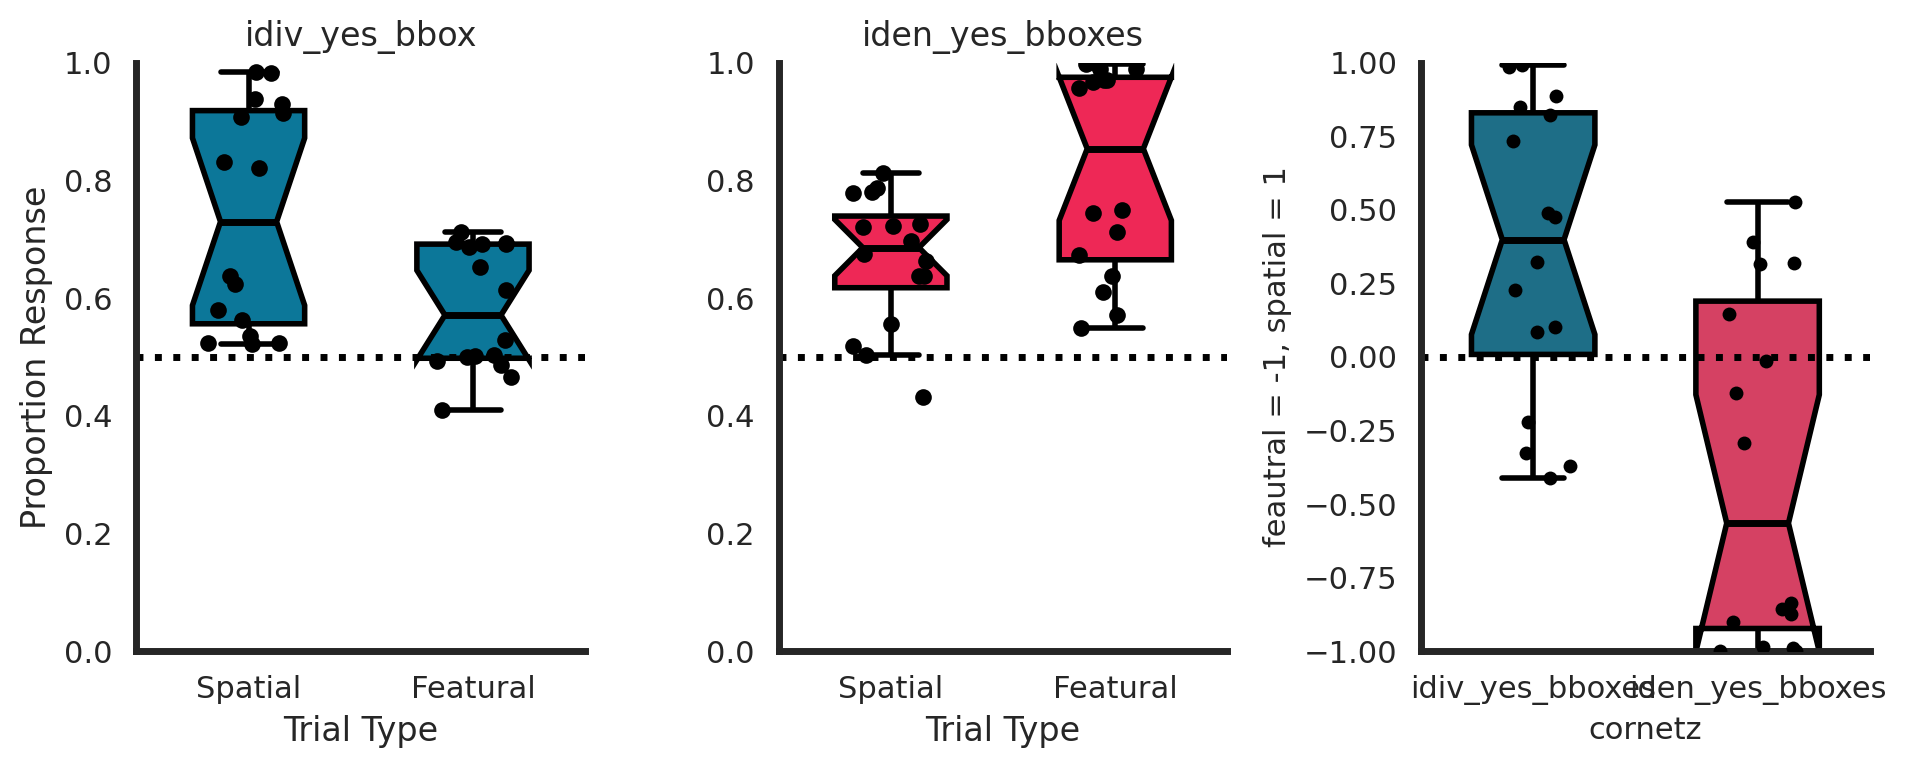

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# EDIT THESE PATHS
# -----------------------
CSV1 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/cornets_bbox/individuation/results/v2/geogaze_model_predictions_individuation_bbox_pred_avg_ratio.csv"
CSV2 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/cornets_bbox/identification/results/geogaze_model_predictions_identification_bbox_pred_avg_ratio.csv"

# -----------------------
# Preprocess A: Spatial vs Featural (mean_ratio per model×condition)
# -----------------------
def load_and_preprocess(csv_path: str) -> pd.DataFrame:
    """
    Reads a CSV with columns: model, condition (spatial/featural/...), ratio
    Keeps only spatial + featural rows, then averages ratio within each model×condition.
    Returns a df with columns: model, condition (Spatial/Featural), mean_ratio
    """
    df = pd.read_csv(csv_path)

    df["condition"] = df["condition"].astype(str).str.strip().str.lower()
    df = df[df["condition"].isin(["spatial", "featural"])].copy()

    df["ratio"] = pd.to_numeric(df["ratio"], errors="coerce")
    df = df.dropna(subset=["ratio"])

    df_avg = (
        df.groupby(["model", "condition"], as_index=False)["ratio"]
          .mean()
          .rename(columns={"ratio": "mean_ratio"})
    )

    df_avg["condition"] = df_avg["condition"].map({"spatial": "Spatial", "featural": "Featural"})
    return df_avg

# -----------------------
# Preprocess B: Conflict -> signed weighting (one dot per model)
# -----------------------
def load_conflict_weighting(csv_path: str, dataset_label: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    df["condition"] = df["condition"].astype(str).str.strip().str.lower()
    df["ratio"] = pd.to_numeric(df["ratio"], errors="coerce")
    df = df.dropna(subset=["ratio"])

    # keep ONLY conflict rows
    df_conf = df[df["condition"].eq("conflict")].copy()

    # average conflict ratio per model (one dot per model)
    conf_avg = (
        df_conf.groupby("model", as_index=False)["ratio"]
               .mean()
               .rename(columns={"ratio": "conflict_ratio"})
    )

    # Convert to signed weighting where + = spatial, - = featural
    # given: conflict_ratio > 0.5 = featural, < 0.5 = spatial
    conf_avg["weighting"] = (0.5 - conf_avg["conflict_ratio"]) * 2

    conf_avg["dataset"] = dataset_label
    return conf_avg

# -----------------------
# Load all data (from the SAME CSVs)
# -----------------------
df1_avg  = load_and_preprocess(CSV1)                 # indiv: Spatial/Featural
df2_avg  = load_and_preprocess(CSV2)                 # ident: Spatial/Featural
df1_conf = load_conflict_weighting(CSV1, "idiv_yes_bboxes")     # conflict weighting
df2_conf = load_conflict_weighting(CSV2, "iden_yes_bboxes")     # conflict weighting
plot_df  = pd.concat([df1_conf, df2_conf], ignore_index=True)

# -----------------------
# Plot: 3 panels in ONE row (keep graphs the same)
# -----------------------
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 3, figsize=(9.7, 4), dpi=200)

# ===== Panel 1: indiv (Spatial/Featural) =====
order_sf = ["Spatial", "Featural"]

sns.boxplot(
    data=df1_avg,
    x="condition",
    y="mean_ratio",
    order=order_sf,
    notch=True,
    width=0.5,
    showfliers=False,
    boxprops=dict(facecolor="#0C7799", edgecolor="black", linewidth=2.0),
    whiskerprops=dict(color="black", linewidth=2.0),
    capprops=dict(color="black", linewidth=2.0),
    medianprops=dict(color="black", linewidth=2.5),
    ax=axes[0],
)
sns.stripplot(
    data=df1_avg,
    x="condition",
    y="mean_ratio",
    order=order_sf,
    jitter=0.18,
    size=6,
    color="black",
    alpha=1,
    zorder=10,
    ax=axes[0],
)
axes[0].axhline(0.5, linestyle=":", linewidth=2.5, color="black")
axes[0].set_title("idiv_yes_bbox")
axes[0].set_xlabel("Trial Type")
axes[0].set_ylabel("Proportion Response")
axes[0].set_ylim(0, 1)

# ===== Panel 2: ident (Spatial/Featural) =====
sns.boxplot(
    data=df2_avg,
    x="condition",
    y="mean_ratio",
    order=order_sf,
    notch=True,
    width=0.5,
    showfliers=False,
    boxprops=dict(facecolor="#EE2856", edgecolor="black", linewidth=2.0),
    whiskerprops=dict(color="black", linewidth=2.0),
    capprops=dict(color="black", linewidth=2.0),
    medianprops=dict(color="black", linewidth=2.5),
    ax=axes[1],
)
sns.stripplot(
    data=df2_avg,
    x="condition",
    y="mean_ratio",
    order=order_sf,
    jitter=0.18,
    size=6,
    color="black",
    alpha=1,
    zorder=10,
    ax=axes[1],
)
axes[1].axhline(0.5, linestyle=":", linewidth=2.5, color="black")
axes[1].set_title("iden_yes_bboxes")
axes[1].set_xlabel("Trial Type")
axes[1].set_ylabel("")
axes[1].set_ylim(0, 1)

# ===== Panel 3: conflict weighting (idiv/iden) =====
order_w = ["idiv_yes_bboxes", "iden_yes_bboxes"]
palette = {"idiv_yes_bboxes": "#0C7799", "iden_yes_bboxes": "#EE2856"}  # blue, pink

sns.boxplot(
    data=plot_df,
    x="dataset",
    y="weighting",
    order=order_w,
    notch=True,
    width=0.55,
    showfliers=False,
    boxprops=dict(edgecolor="black", linewidth=2),
    whiskerprops=dict(color="black", linewidth=2),
    capprops=dict(color="black", linewidth=2),
    medianprops=dict(color="black", linewidth=2.5),
    palette=palette,
    ax=axes[2],
)
sns.stripplot(
    data=plot_df,
    x="dataset",
    y="weighting",
    order=order_w,
    color="black",
    alpha=1,
    jitter=0.18,
    size=5,
    zorder=10,
    ax=axes[2],
)
axes[2].axhline(0, linestyle=":", linewidth=2.5, color="black")
axes[2].set_xlabel("cornetz", fontsize=11)
axes[2].set_ylabel("feautral = -1, spatial = 1", fontsize=11)
axes[2].set_ylim(-1, 1)

# ===== Shared styling (same as your code) =====
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2.5)
    ax.spines["bottom"].set_linewidth(2.5)
    ax.tick_params(axis="both", width=2, length=5)

plt.tight_layout()
plt.show()